In [1]:
# Imports
import pandas as pd
import numpy as np
import pyranges as pr
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc


In [4]:
# Load top genes
importance_df = pd.read_csv("/Users/halimaabdulsalam/My_files/ScRNA-ML/Multiome-ML-scRNA-scATAC/results/files/feature_importance.csv")

# Keep only gene names
importance_df["Gene"] = importance_df["Feature"].apply(lambda x: x.replace("_RNA", "").replace("_ATAC", ""))

# Drop duplicates in case the same gene appears for both modalities
top_genes = importance_df["Gene"].drop_duplicates().head(100).tolist()



In [ ]:
# Extract Alzheimer's-Specific GWAS from Downloaded full GWAS catalog
# Load full GWAS catalog
df = pd.read_csv("/Users/halimaabdulsalam/My_files/ScRNA-ML/data_not_pushed/gwas_catalog_v1.0-associations_e114_r2025-06-10.tsv", sep="\t", low_memory=False)

# Filter rows containing 'Alzheimer' (case-insensitive)
alz_df = df[df['DISEASE/TRAIT'].str.contains('alzheimer', case=False, na=False)]

# Check 
print(f"Found {alz_df.shape[0]} Alzheimer-related GWAS hits.")

# Optionally save
alz_df.to_csv("alzheimers_gwas_filtered.tsv", sep="\t", index=False)

# Extract gene symbols
mapped_genes = set()
for genes in alz_df['MAPPED_GENE'].dropna():
    for gene in genes.split(','):
        if gene.strip() != 'NR':  # 'NR' = not reported
            mapped_genes.add(gene.strip())

print(f"Extracted {len(mapped_genes)} unique genes.")

# Overlap mapped genes
ad_hits_in_classifier = set(top_genes).intersection(mapped_genes)
print(f"Overlap with AD GWAS genes: {len(ad_hits_in_classifier)}")
print("Genes:", ad_hits_in_classifier)

# Export 
pd.Series(list(ad_hits_in_classifier)).to_csv("/Users/halimaabdulsalam/My_files/ScRNA-ML/Multiome-ML-scRNA-scATAC/results/files/ad_classifier_overlap.csv", index=False)


14 GWAS genes found in RNA data: ['TCF4', 'LEF1-AS1', 'L3MBTL4', 'ANK3', 'ROBO1', 'MEF2C', 'LINGO2', 'CUX2', 'TSHZ2', 'BANK1', 'RAB31', 'TCF7L2', 'ARHGAP24', 'MIAT']


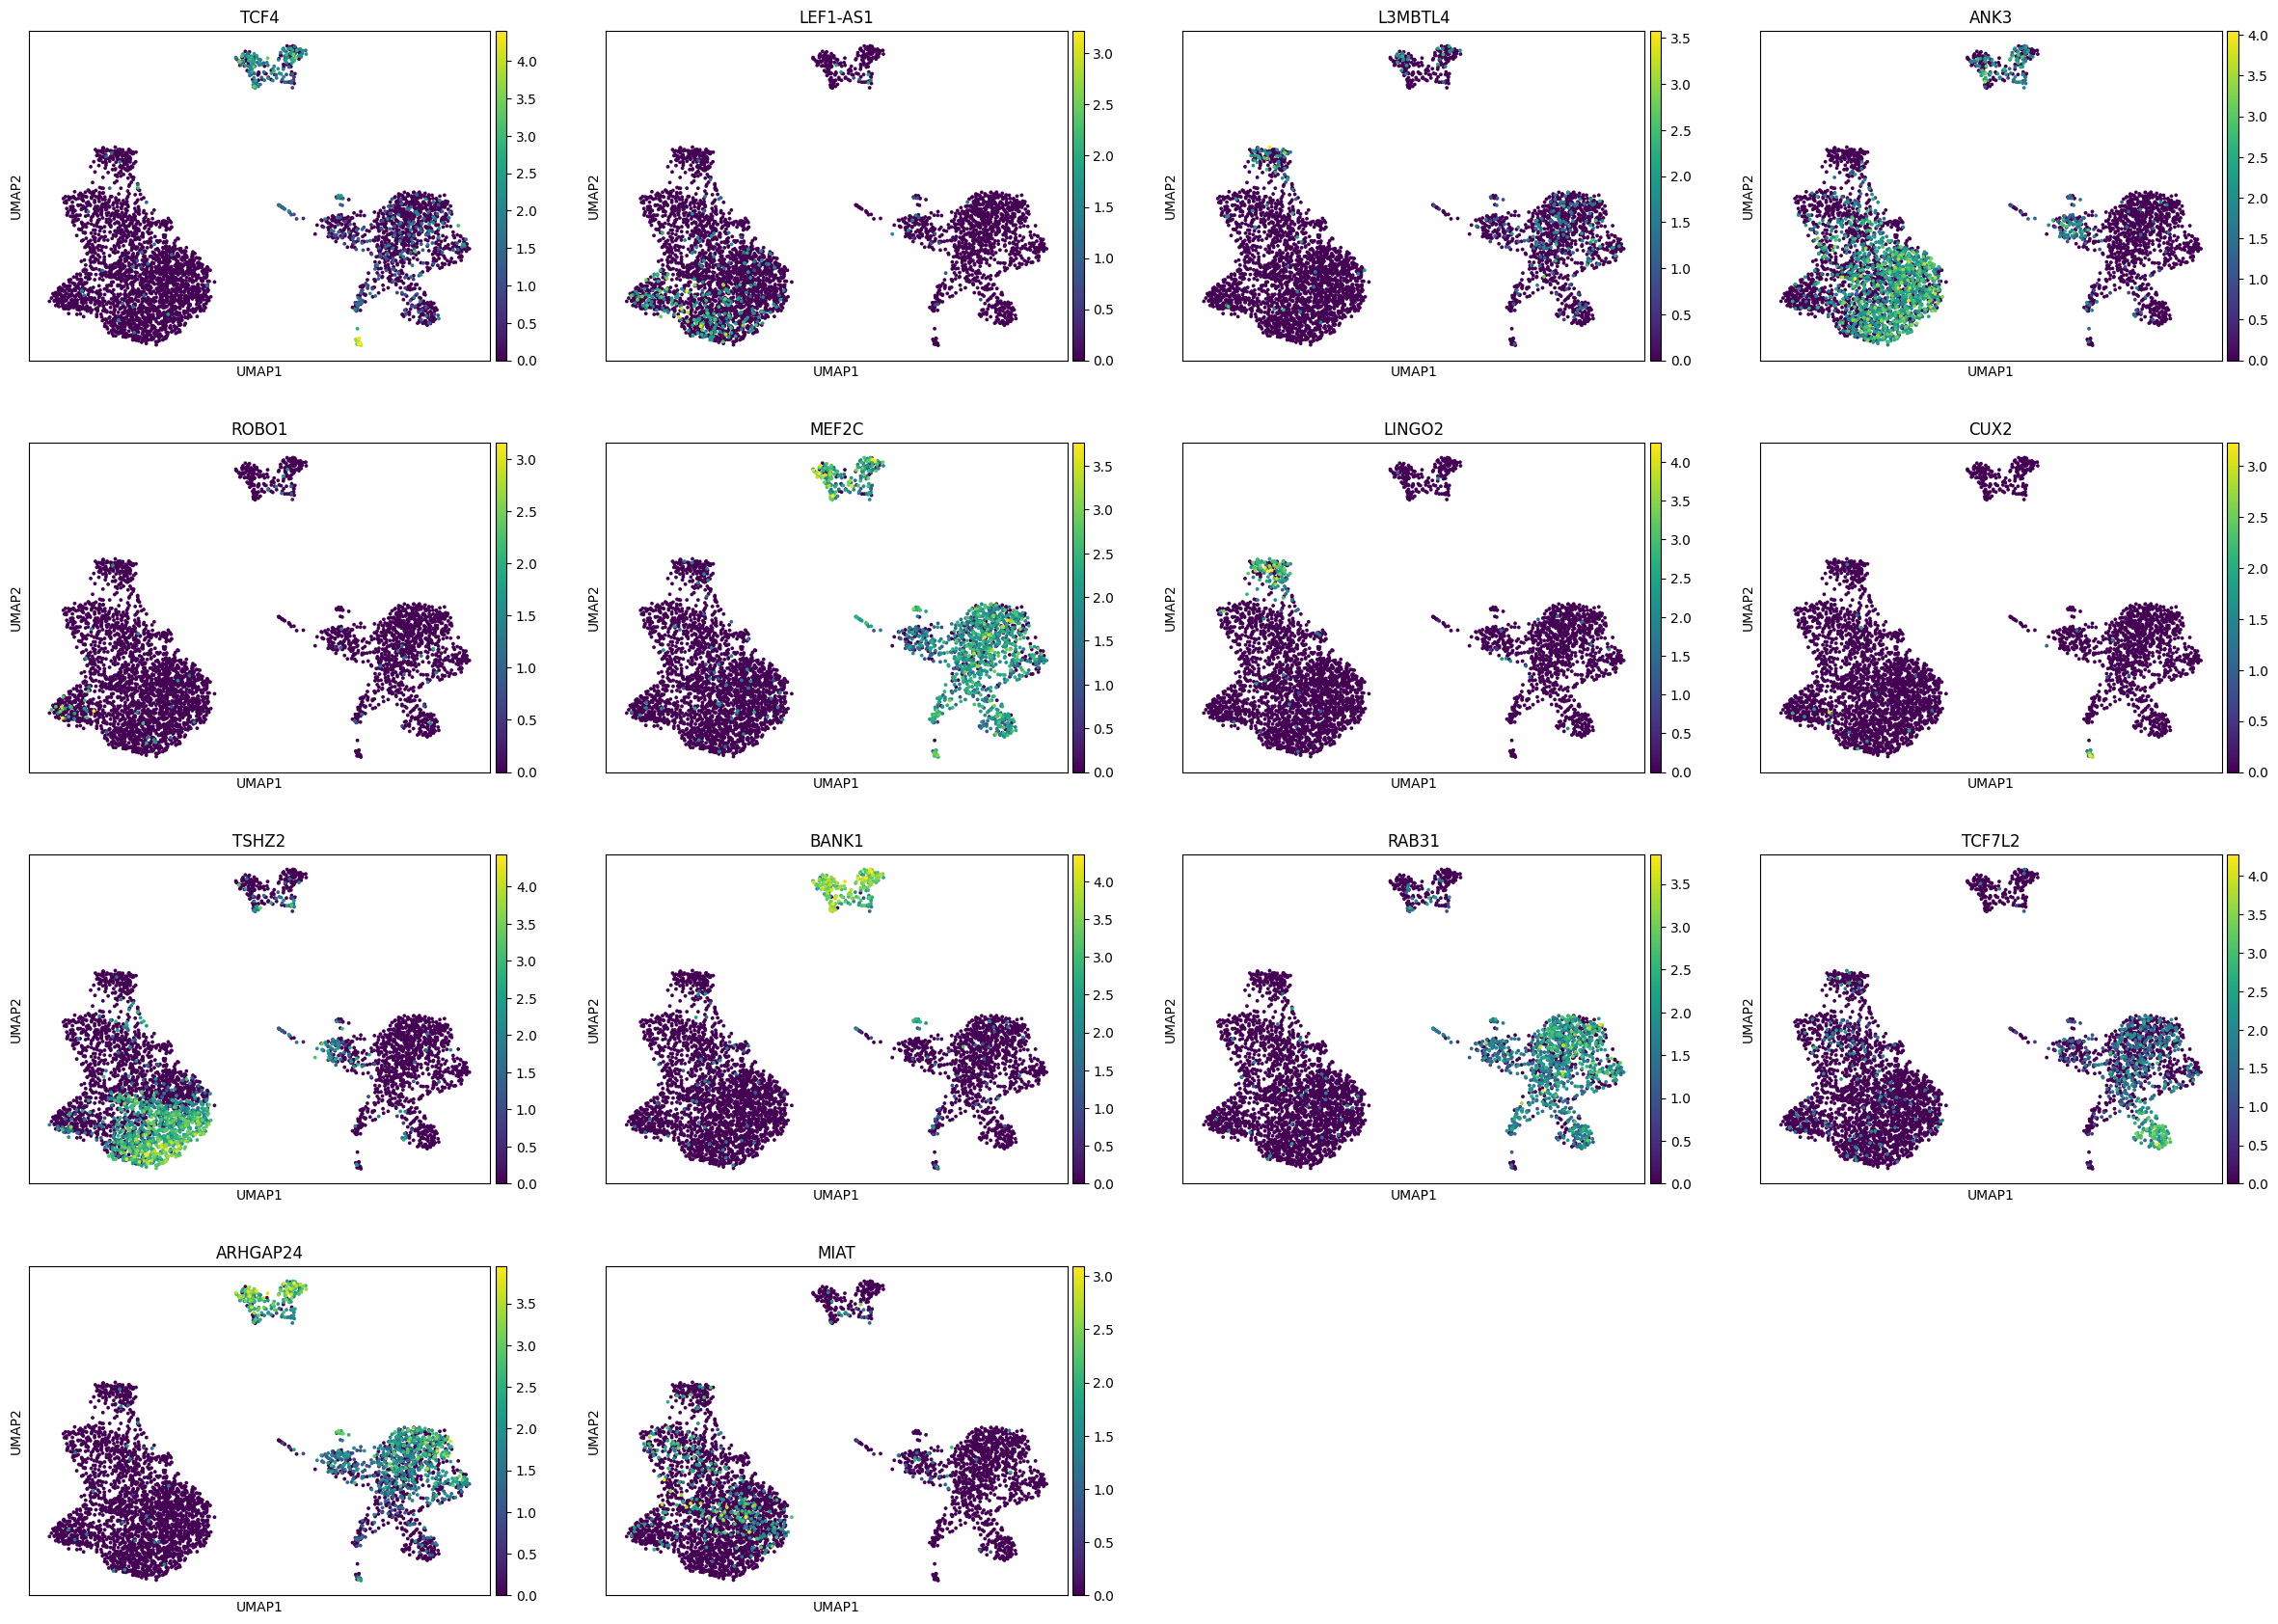

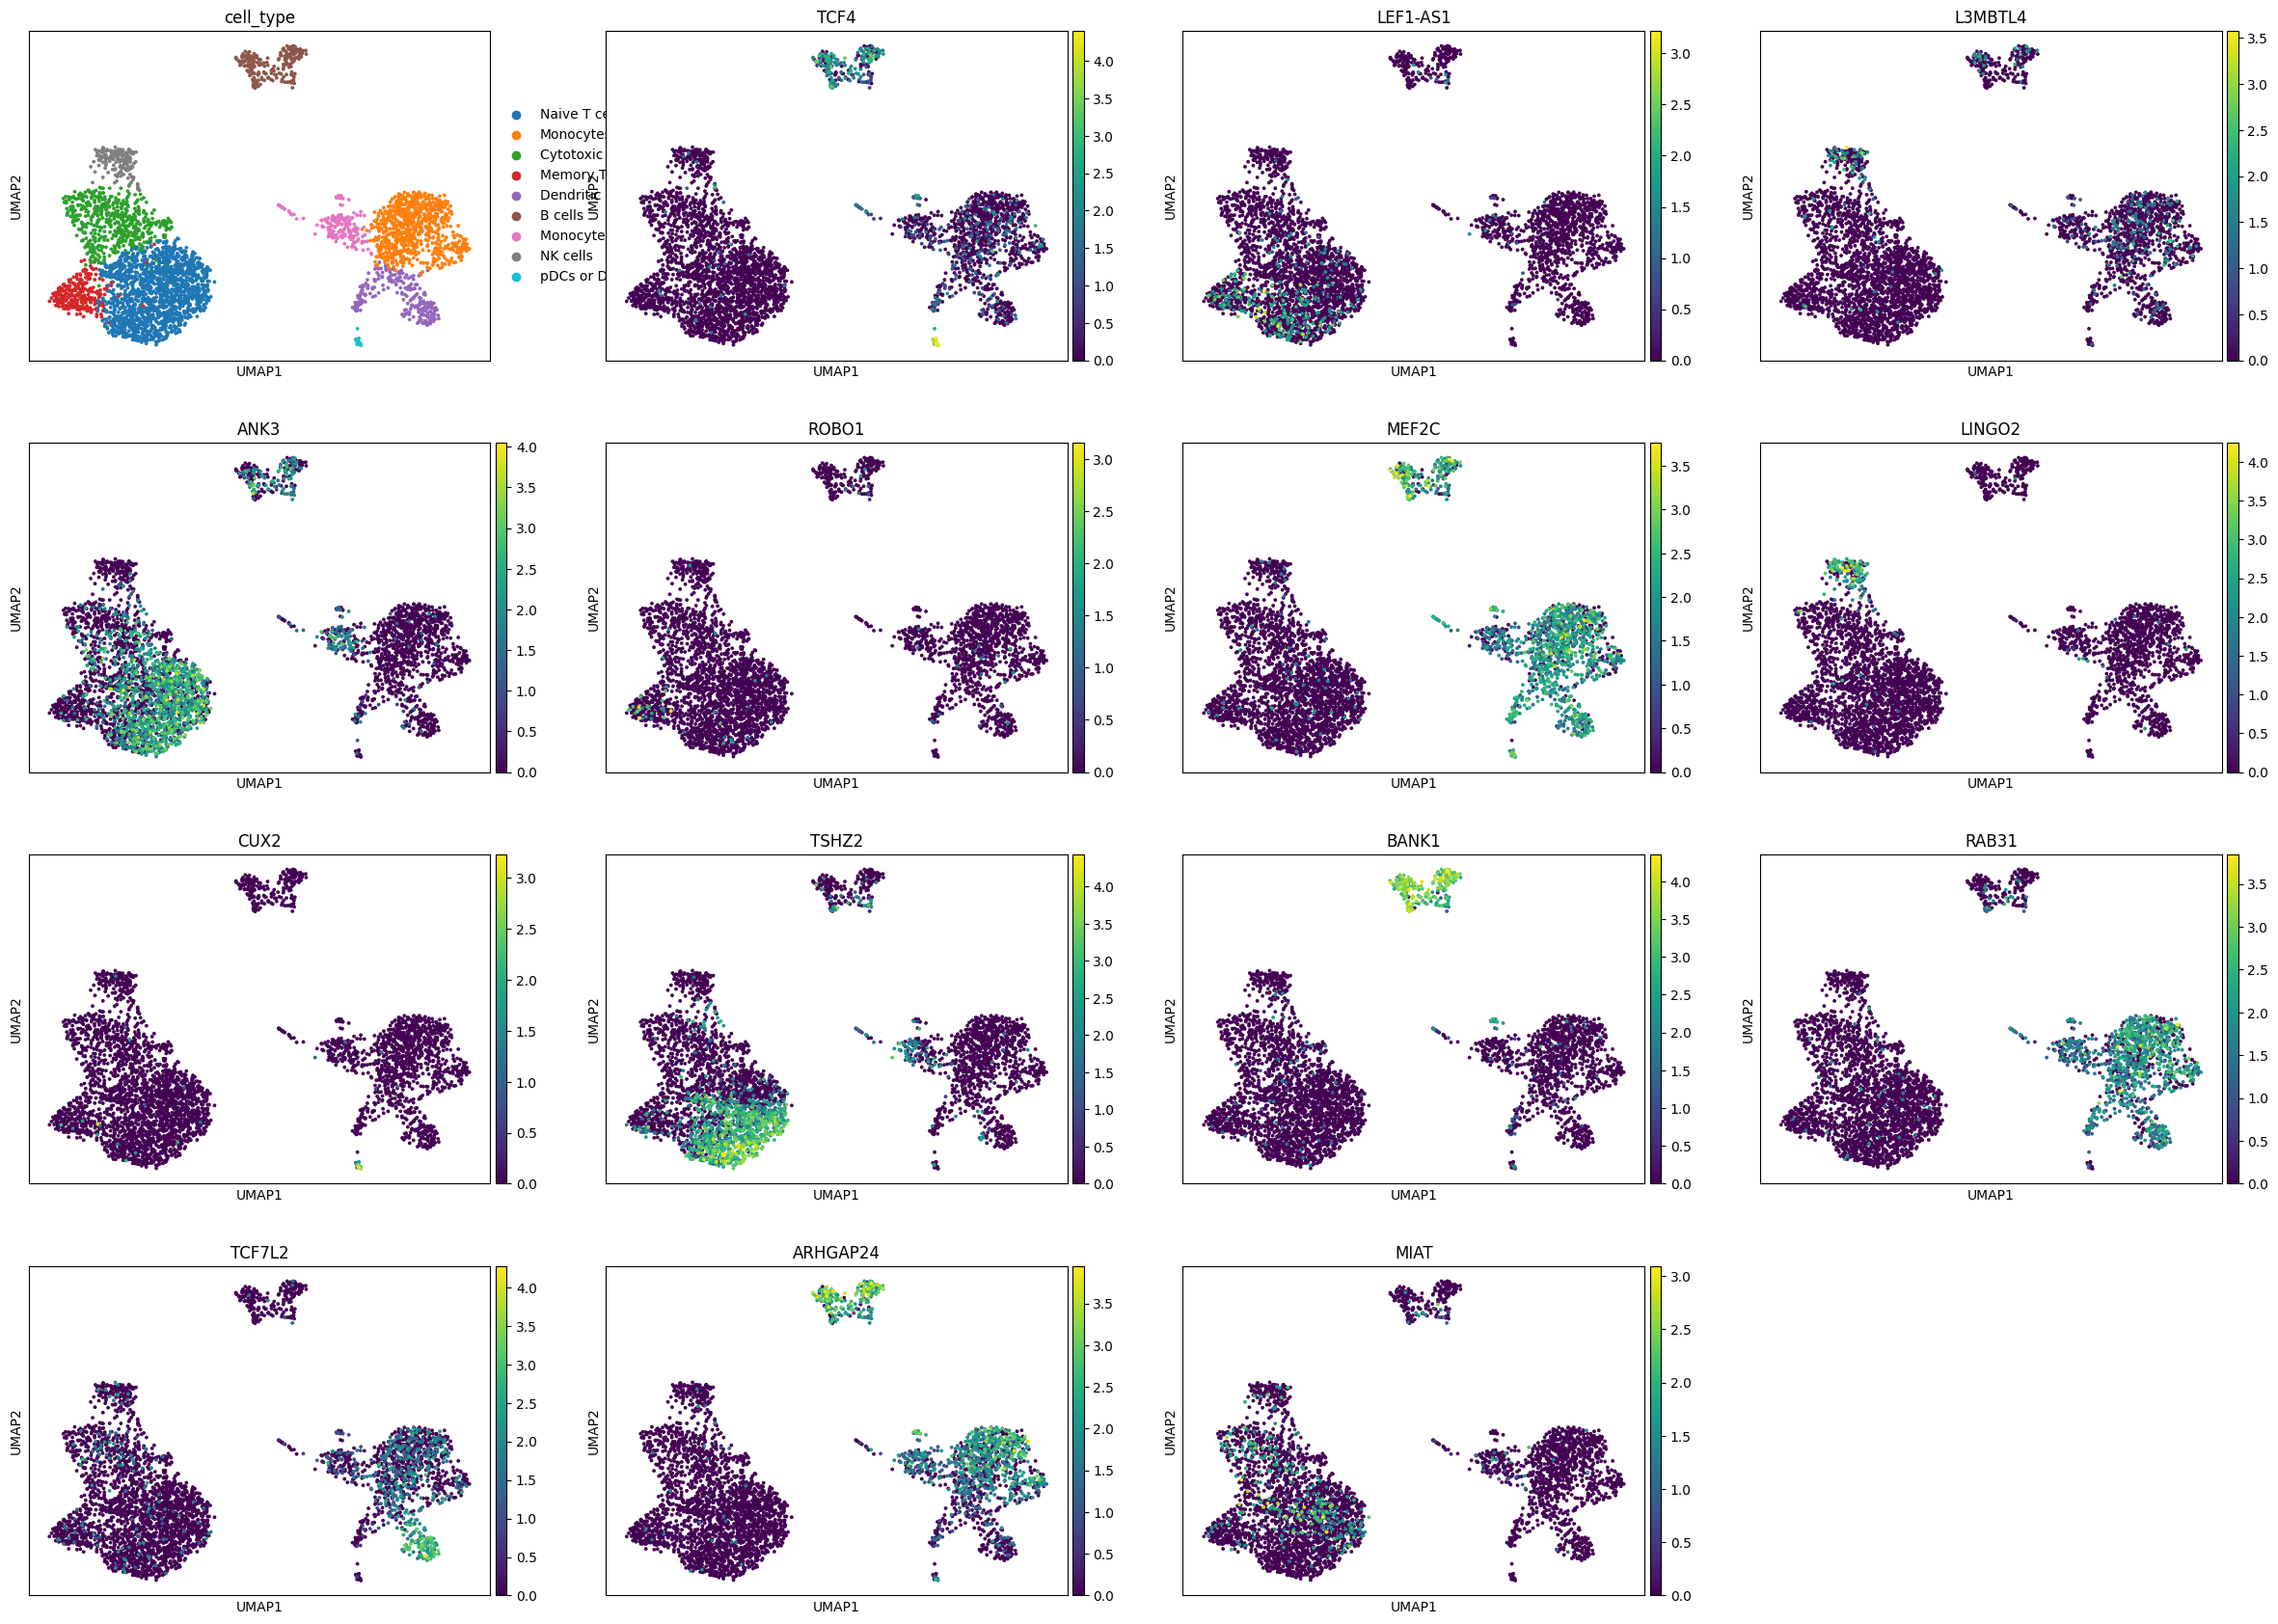

In [24]:
# Load scRNA expression data
adata = sc.read_h5ad("/Users/halimaabdulsalam/My_files/ScRNA-ML/Multiome-ML-scRNA-scATAC/results/files/rna_annotated_cleaned.h5ad")

# Confirm that overlapped genes are in the RNA features
valid_genes = [gene for gene in ad_hits_in_classifier if gene in adata.var_names]
print(f"{len(valid_genes)} GWAS genes found in RNA data: {valid_genes}")

# overlay them in UMAP if genes are RNA features
sc.pl.umap(adata, color=valid_genes, cmap="viridis", show=False)
plt.savefig("/Users/halimaabdulsalam/My_files/ScRNA-ML/Multiome-ML-scRNA-scATAC/results/plots/umap_ad_gwas_genes.png", dpi=300)


# visualize expression of these genes alongside cell types
sc.pl.umap(adata, color=['cell_type'] + valid_genes, cmap="viridis", show=False)
plt.savefig("/Users/halimaabdulsalam/My_files/ScRNA-ML/Multiome-ML-scRNA-scATAC/results/plots/umap_ad_gwas_genes_x_expression.png", dpi=300)



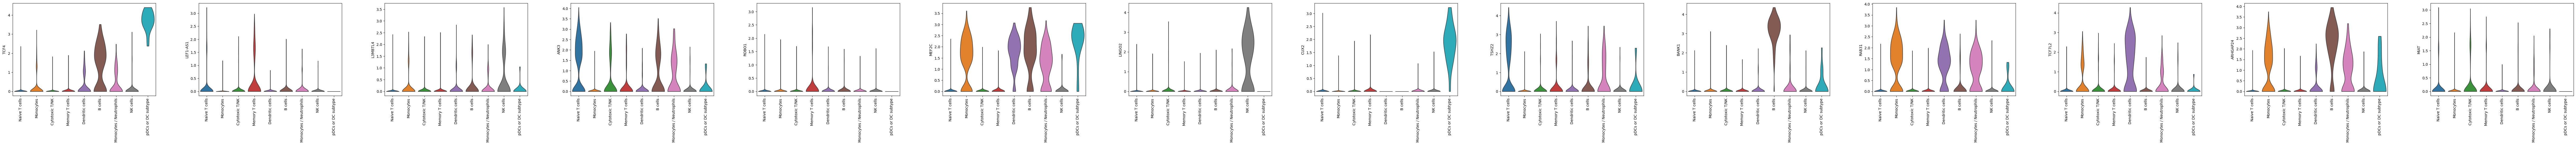

In [25]:
# violin plot gene expression per cell type
sc.pl.violin(adata, keys=list(valid_genes), groupby="cell_type", stripplot=False, rotation=90, show=False)
plt.savefig("/Users/halimaabdulsalam/My_files/ScRNA-ML/Multiome-ML-scRNA-scATAC/results/plots/umap_ad_gwas_genes_x_expression_violin.png", dpi=300)
